<a href="https://colab.research.google.com/github/albertbolanoss/labs_deep_learning/blob/fruit-single-shot-detection/notebooks/fruit-single-detector/02_advanced_training_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Advanced Fruit Single Shot Detection (SSD) Model

This notebook implements a state-of-the-art object detection model using Transfer Learning to detect and localize fruits with high precision.

**Key Features:**
- Transfer Learning with MobileNetV2 backbone
- Advanced loss functions (Focal Loss + Smooth L1 Loss)
- Proper data augmentation for object detection
- Comprehensive evaluation and visualization
- Model checkpointing and saving

**Author:** Computer Vision Engineer  
**Dataset:** Fruit Images for Object Detection (Kaggle)

In [2]:
# Install required packages
!pip install -q tensorflow opencv-python-headless matplotlib scikit-learn

# Core imports
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import random
import xml.etree.ElementTree as ET
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

# TensorFlow and Keras imports
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing.image import img_to_array, load_img
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
import tensorflow.keras.backend as K

# Google Colab specific
from google.colab import userdata

print(f"TensorFlow Version: {tf.__version__}")
print(f"GPU Available: {tf.config.list_physical_devices('GPU')}")

# Set random seeds for reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)

TensorFlow Version: 2.19.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Configuration & Hyperparameters

Define all configuration parameters.

In [3]:
# Dataset Configuration
KAGGLE_DATASET = "mbkinaci/fruit-images-for-object-detection"
BASE_DIR = "/content/fruit_data"
MODEL_TO_SAVE = "fruit_detector_v1.keras"

# Model Configuration
IMG_WIDTH = 224
IMG_HEIGHT = 224
GRID_SIZE = 7
NUM_CLASSES = 3

# Class Mapping
CLASS_MAP = {"apple": 0, "banana": 1, "orange": 2}
INV_CLASS_MAP = {0: "apple", 1: "banana", 2: "orange"}
CLASS_COLORS = {0: 'red', 1: 'yellow', 2: 'orange'}

# Training Hyperparameters
BATCH_SIZE = 16
EPOCHS = 50
LEARNING_RATE = 1e-4
PATIENCE = 10

# Loss weights
LAMBDA_COORD = 5.0
LAMBDA_NOOBJ = 0.5

print("Configuration loaded successfully!")
print(f"Image Size: {IMG_WIDTH}x{IMG_HEIGHT}")
print(f"Grid Size: {GRID_SIZE}x{GRID_SIZE}")
print(f"Classes: {list(CLASS_MAP.keys())}")

Configuration loaded successfully!
Image Size: 224x224
Grid Size: 7x7
Classes: ['apple', 'banana', 'orange']


## 3. Dataset Download

Download the fruit detection dataset from Kaggle.

In [4]:
# Configure Kaggle API
os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USERNAME')
os.environ['KAGGLE_KEY'] = userdata.get('KAGGLE_KEY')

# Download and extract dataset
if not os.path.exists(BASE_DIR):
    print("Downloading dataset...")
    !kaggle datasets download -d {KAGGLE_DATASET}
    !unzip -q fruit-images-for-object-detection.zip -d {BASE_DIR}
    print(f"Dataset downloaded to {BASE_DIR}")
else:
    print("Dataset already exists.")

# Verify structure
print("\nDataset structure:")
for folder in os.listdir(BASE_DIR):
    folder_path = os.path.join(BASE_DIR, folder)
    if os.path.isdir(folder_path):
        print(f"  {folder}/")

Dataset URL: https://www.kaggle.com/datasets/mbkinaci/fruit-images-for-object-detection
License(s): CC0-1.0
  0% 0.00/28.4M [00:00<?, ?B/s]
100% 28.4M/28.4M [00:00<00:00, 1.77GB/s]
Dataset downloaded to /content/fruit_data

Dataset structure:
  train_zip/
  test_zip/


## 4. Data Parsing & Preprocessing

In [5]:
def get_image_dimensions(img_path):
    try:
        img = cv2.imread(img_path)
        if img is not None:
            height, width = img.shape[:2]
            return width, height
        return None, None
    except:
        return None, None

def parse_xml_annotation(xml_path, img_dir):
    try:
        tree = ET.parse(xml_path)
        root = tree.getroot()
        filename = root.find("filename").text
        img_path = os.path.join(img_dir, filename)

        if not os.path.exists(img_path):
            return None, None

        w_orig, h_orig = get_image_dimensions(img_path)
        if w_orig is None:
            return None, None

        boxes = []
        for obj in root.findall("object"):
            name = obj.find("name").text
            if name not in CLASS_MAP:
                continue

            label = CLASS_MAP[name]
            bndbox = obj.find("bndbox")
            xmin = int(bndbox.find("xmin").text)
            ymin = int(bndbox.find("ymin").text)
            xmax = int(bndbox.find("xmax").text)
            ymax = int(bndbox.find("ymax").text)

            xmin_norm = max(0, min(1, xmin / w_orig))
            ymin_norm = max(0, min(1, ymin / h_orig))
            xmax_norm = max(0, min(1, xmax / w_orig))
            ymax_norm = max(0, min(1, ymax / h_orig))

            if xmax_norm > xmin_norm and ymax_norm > ymin_norm:
                boxes.append([xmin_norm, ymin_norm, xmax_norm, ymax_norm, label])

        return img_path, boxes
    except:
        return None, None

def load_dataset(directory):
    images = []
    annotations = []
    print(f"Loading data from: {directory}")

    for root_dir, dirs, files in os.walk(directory):
        for file in files:
            if file.endswith(".xml"):
                xml_path = os.path.join(root_dir, file)
                img_path, boxes = parse_xml_annotation(xml_path, root_dir)

                if img_path is None or not boxes:
                    continue

                try:
                    img = load_img(img_path, target_size=(IMG_HEIGHT, IMG_WIDTH))
                    img_arr = img_to_array(img) / 255.0
                    images.append(img_arr)
                    annotations.append(boxes)
                except:
                    pass

    print(f"  Loaded {len(images)} images")
    return np.array(images, dtype="float32"), annotations

print("Loading Training Data...")
X_train_full, train_annotations = load_dataset(os.path.join(BASE_DIR, "train_zip", "train"))

print("Loading Test Data...")
X_test_full, test_annotations = load_dataset(os.path.join(BASE_DIR, "test_zip", "test"))

X_val, X_test, val_annotations, test_annotations = train_test_split(
    X_test_full, test_annotations, test_size=0.5, random_state=SEED, shuffle=True
)

print(f"\nDataset Summary:")
print(f"Training: {len(X_train_full)}")
print(f"Validation: {len(X_val)}")
print(f"Test: {len(X_test)}")

Loading Training Data...
Loading data from: /content/fruit_data/train_zip/train
  Loaded 240 images
Loading Test Data...
Loading data from: /content/fruit_data/test_zip/test
  Loaded 60 images

Dataset Summary:
Training: 240
Validation: 30
Test: 30


## 5. Data Visualization

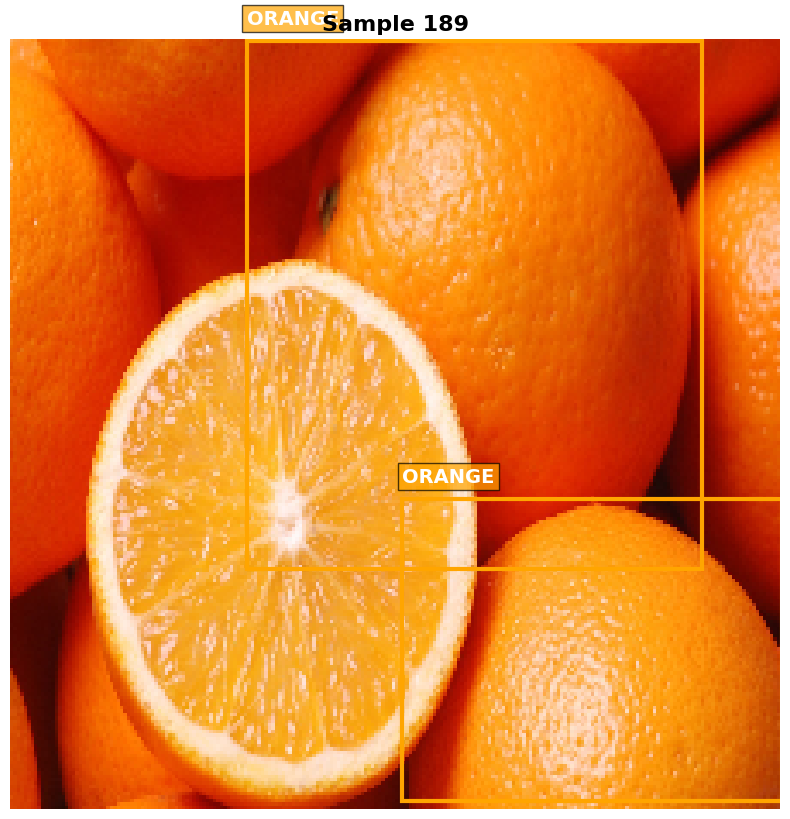

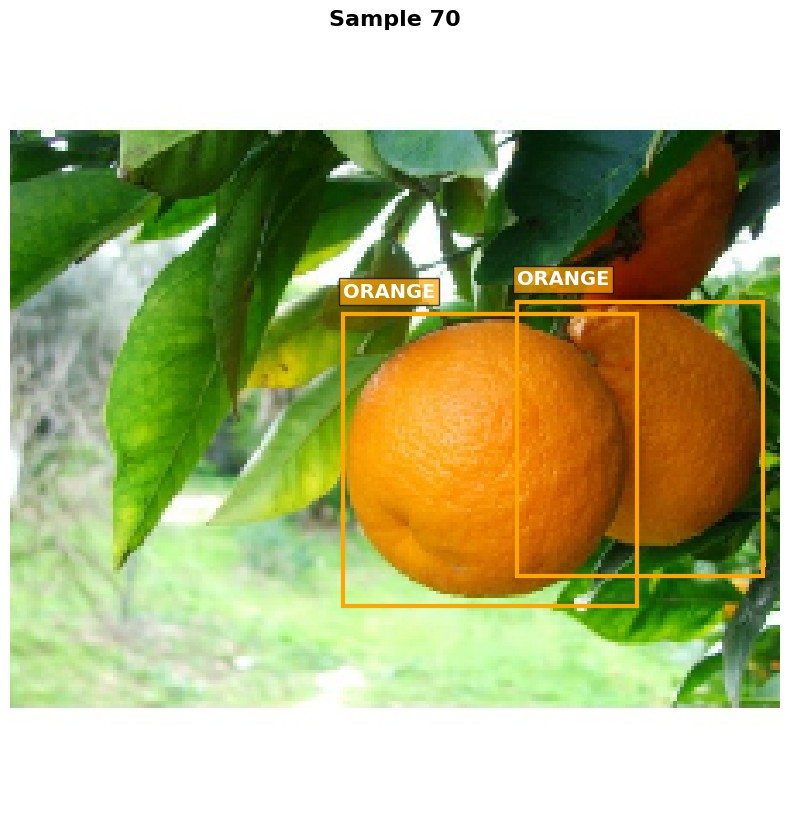

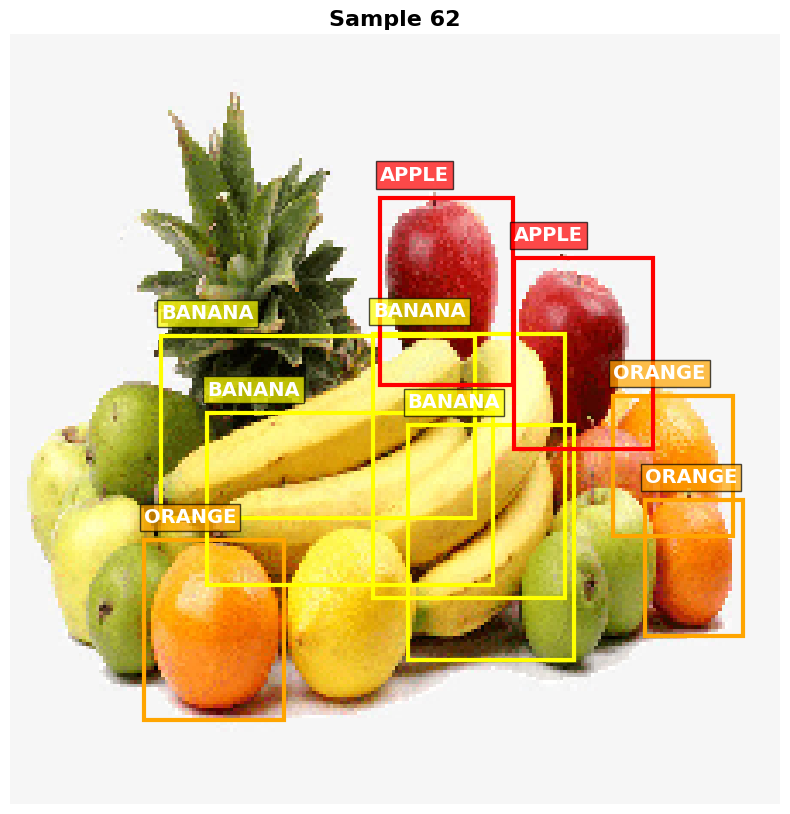

In [7]:
def visualize_sample(images, annotations, index):
    img = images[index]
    boxes = annotations[index]

    fig, ax = plt.subplots(1, figsize=(10, 10))
    ax.imshow(img)

    img_h, img_w = img.shape[:2]

    for box in boxes:
        xmin_n, ymin_n, xmax_n, ymax_n, label_idx = box
        xmin, ymin = xmin_n * img_w, ymin_n * img_h
        xmax, ymax = xmax_n * img_w, ymax_n * img_h

        class_name = INV_CLASS_MAP[int(label_idx)]
        color = CLASS_COLORS[int(label_idx)]

        rect = patches.Rectangle(
            (xmin, ymin), xmax - xmin, ymax - ymin,
            linewidth=3, edgecolor=color, facecolor='none'
        )
        ax.add_patch(rect)

        ax.text(xmin, ymin - 5, class_name.upper(), color='white',
                fontsize=14, weight='bold',
                bbox=dict(facecolor=color, alpha=0.7, pad=3))

    ax.axis('off')
    ax.set_title(f"Sample {index}", fontsize=16, weight='bold')
    plt.show()

for i in range(3):
    idx = random.randint(0, len(X_train_full) - 1)
    visualize_sample(X_train_full, train_annotations, idx)

## 6. Target Encoding for Grid-Based Detection

In [8]:
def encode_target(annotations, grid_size=GRID_SIZE, num_classes=NUM_CLASSES):
    target = np.zeros((grid_size, grid_size, 5 + num_classes), dtype=np.float32)

    for box in annotations:
        xmin, ymin, xmax, ymax, label = box
        cx = (xmin + xmax) / 2.0
        cy = (ymin + ymax) / 2.0
        w = xmax - xmin
        h = ymax - ymin

        col = int(cx * grid_size)
        row = int(cy * grid_size)
        col = min(col, grid_size - 1)
        row = min(row, grid_size - 1)

        if target[row, col, 0] == 0:
            target[row, col, 0] = 1.0
            target[row, col, 1:5] = [cx, cy, w, h]
            target[row, col, 5 + int(label)] = 1.0

    return target

print("Encoding targets...")
y_train = np.array([encode_target(ann) for ann in train_annotations])
y_val = np.array([encode_target(ann) for ann in val_annotations])
y_test = np.array([encode_target(ann) for ann in test_annotations])

print(f"y_train: {y_train.shape}")
print(f"y_val: {y_val.shape}")
print(f"y_test: {y_test.shape}")

Encoding targets...
y_train: (240, 7, 7, 8)
y_val: (30, 7, 7, 8)
y_test: (30, 7, 7, 8)


## 7. Data Augmentation

In [9]:
def augment_image_and_boxes(image, boxes, flip_prob=0.5):
    aug_image = image.copy()
    aug_boxes = [box.copy() for box in boxes]

    if random.random() < flip_prob:
        aug_image = np.fliplr(aug_image)
        for box in aug_boxes:
            xmin, ymin, xmax, ymax, label = box
            box[0] = 1.0 - xmax
            box[2] = 1.0 - xmin

    if random.random() < 0.5:
        brightness = random.uniform(0.8, 1.2)
        aug_image = np.clip(aug_image * brightness, 0, 1)

    if random.random() < 0.5:
        contrast = random.uniform(0.8, 1.2)
        mean = aug_image.mean()
        aug_image = np.clip((aug_image - mean) * contrast + mean, 0, 1)

    return aug_image, aug_boxes

class DataGenerator(keras.utils.Sequence):
    def __init__(self, images, annotations, batch_size=BATCH_SIZE, shuffle=True, augment=False):
        self.images = images
        self.annotations = annotations
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.augment = augment
        self.indexes = np.arange(len(self.images))
        self.on_epoch_end()

    def __len__(self):
        return int(np.ceil(len(self.images) / self.batch_size))

    def __getitem__(self, index):
        start_idx = index * self.batch_size
        end_idx = min((index + 1) * self.batch_size, len(self.images))
        batch_indexes = self.indexes[start_idx:end_idx]

        X_batch, y_batch = [], []
        for idx in batch_indexes:
            image, boxes = self.images[idx], self.annotations[idx]
            if self.augment:
                image, boxes = augment_image_and_boxes(image, boxes)
            target = encode_target(boxes)
            X_batch.append(image)
            y_batch.append(target)

        return np.array(X_batch), np.array(y_batch)

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indexes)

train_generator = DataGenerator(X_train_full, train_annotations, shuffle=True, augment=True)
val_generator = DataGenerator(X_val, val_annotations, shuffle=False, augment=False)

print(f"Training batches: {len(train_generator)}")
print(f"Validation batches: {len(val_generator)}")

Training batches: 15
Validation batches: 2


## 8. Model Architecture - Transfer Learning with MobileNetV2

In [10]:
def build_detection_model():
    inputs = layers.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3))

    backbone = MobileNetV2(
        input_shape=(IMG_HEIGHT, IMG_WIDTH, 3),
        include_top=False,
        weights='imagenet',
        alpha=1.0
    )

    for layer in backbone.layers[:-30]:
        layer.trainable = False

    x = backbone(inputs, training=False)
    x = layers.Conv2D(256, (3, 3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Conv2D(128, (3, 3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.2)(x)

    output_channels = 5 + NUM_CLASSES
    x = layers.Conv2D(output_channels, (1, 1), padding='same')(x)
    outputs = layers.Resizing(GRID_SIZE, GRID_SIZE)(x)

    model = models.Model(inputs=inputs, outputs=outputs, name='FruitDetector')
    return model

print("Building model...")
model = build_detection_model()
model.summary()

trainable_params = np.sum([K.count_params(w) for w in model.trainable_weights])
print(f"\nTrainable parameters: {trainable_params:,}")

Building model...
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "FruitDetector"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 7, 7, 256)      │     2,949,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 7, 7, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 7, 7, 128)      │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 8)        │         1,032 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resizing (Resizing)             │ (None, 7, 7, 8)        │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,504,968 (21.00 MB)

 Trainable params: 4,772,616 (18.21 MB)

 Non-trainable params: 732,352 (2.79 MB)


Trainable parameters: 4,772,616


## 9. Custom Loss Functions

In [19]:
def focal_loss(y_true, y_pred, alpha=0.25, gamma=2.0):
    epsilon = K.epsilon()
    y_pred = K.clip(y_pred, epsilon, 1.0 - epsilon)
    cross_entropy = -y_true * K.log(y_pred)
    weight = alpha * y_true * K.pow((1 - y_pred), gamma)
    return K.sum(weight * cross_entropy, axis=-1)

def smooth_l1_loss(y_true, y_pred, beta=1.0):
    diff = K.abs(y_true - y_pred)
    less_than_beta = K.cast(K.less(diff, beta), 'float32')
    loss = (less_than_beta * 0.5 * diff ** 2 / beta) + ((1 - less_than_beta) * (diff - 0.5 * beta))
    return K.sum(loss, axis=-1)

def detection_loss(y_true, y_pred):
    true_conf = y_true[..., 0:1]
    true_box = y_true[..., 1:5]
    true_class = y_true[..., 5:]

    pred_conf = K.sigmoid(y_pred[..., 0:1])
    pred_box = y_pred[..., 1:5]
    pred_class = K.softmax(y_pred[..., 5:])

    obj_mask = true_conf
    noobj_mask = 1 - obj_mask

    conf_loss_obj = obj_mask * K.binary_crossentropy(true_conf, pred_conf)
    conf_loss_noobj = noobj_mask * K.binary_crossentropy(true_conf, pred_conf)
    conf_loss = K.sum(conf_loss_obj) + LAMBDA_NOOBJ * K.sum(conf_loss_noobj)

    box_diff = K.abs(true_box - pred_box)
    loc_loss = K.sum(obj_mask * box_diff)
    loc_loss = LAMBDA_COORD * loc_loss

    class_diff = K.sum(K.square(true_class - pred_class), axis=-1, keepdims=True)
    class_loss = K.sum(obj_mask * class_diff)

    return conf_loss + loc_loss + class_loss

def confidence_accuracy(y_true, y_pred):
    true_conf = y_true[..., 0]
    pred_conf = K.sigmoid(y_pred[..., 0])
    pred_conf_binary = K.cast(K.greater(pred_conf, 0.5), 'float32')
    return K.mean(K.equal(true_conf, pred_conf_binary))

def mean_iou(y_true, y_pred):
    obj_mask = K.expand_dims(y_true[..., 0], axis=-1)
    true_box = y_true[..., 1:5]
    pred_box = y_pred[..., 1:5]
    intersection = K.sum(K.minimum(true_box, pred_box) * obj_mask, axis=-1)
    union = K.sum(K.maximum(true_box, pred_box) * obj_mask, axis=-1)
    return K.mean(intersection / (union + K.epsilon()))

print("Loss functions defined!")

Loss functions defined!


## 10. Model Compilation

In [20]:
optimizer = optimizers.Adam(learning_rate=LEARNING_RATE)

model.compile(
    optimizer=optimizer,
    loss=detection_loss,
    metrics=[confidence_accuracy, mean_iou]
)

print("Model compiled!")
print(f"Optimizer: Adam")
print(f"Learning rate: {LEARNING_RATE}")
print(f"Batch size: {BATCH_SIZE}")

Model compiled!
Optimizer: Adam
Learning rate: 0.0001
Batch size: 16


## 11. Training Callbacks

In [21]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=PATIENCE, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-7, verbose=1),
    ModelCheckpoint('/content/best_model.keras', monitor='val_loss', save_best_only=True, verbose=1)
]

print("Callbacks configured")

Callbacks configured


## 12. Model Training

In [22]:
print("Starting training...")
print("=" * 60)

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)

print("\n" + "=" * 60)
print("Training completed!")

Starting training...
Epoch 1/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - confidence_accuracy: 0.4807 - loss: 1343.0519 - mean_iou: -0.0264
Epoch 1: val_loss improved from inf to 926.91138, saving model to /content/best_model.keras
15/15 ━━━━━━━━━━━━━━━━━━━━ 47s 1s/step - confidence_accuracy: 0.4820 - loss: 1342.5863 - mean_iou: -0.0262 - val_confidence_accuracy: 0.5206 - val_loss: 926.9114 - val_mean_iou: 0.0090 - learning_rate: 1.0000e-04
Epoch 2/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - confidence_accuracy: 0.5327 - loss: 1228.4150 - mean_iou: -0.0101
Epoch 2: val_loss improved from 926.91138 to 828.47632, saving model to /content/best_model.keras
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 125ms/step - confidence_accuracy: 0.5329 - loss: 1231.7227 - mean_iou: -0.0101 - val_confidence_accuracy: 0.5324 - val_loss: 828.4763 - val_mean_iou: 0.0045 - learning_rate: 1.0000e-04
Epoch 3/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - confidence_accuracy: 0.5444 - loss: 1192.6337 - mean_iou: -0.0126
Epoc

## 13. Training History Visualization

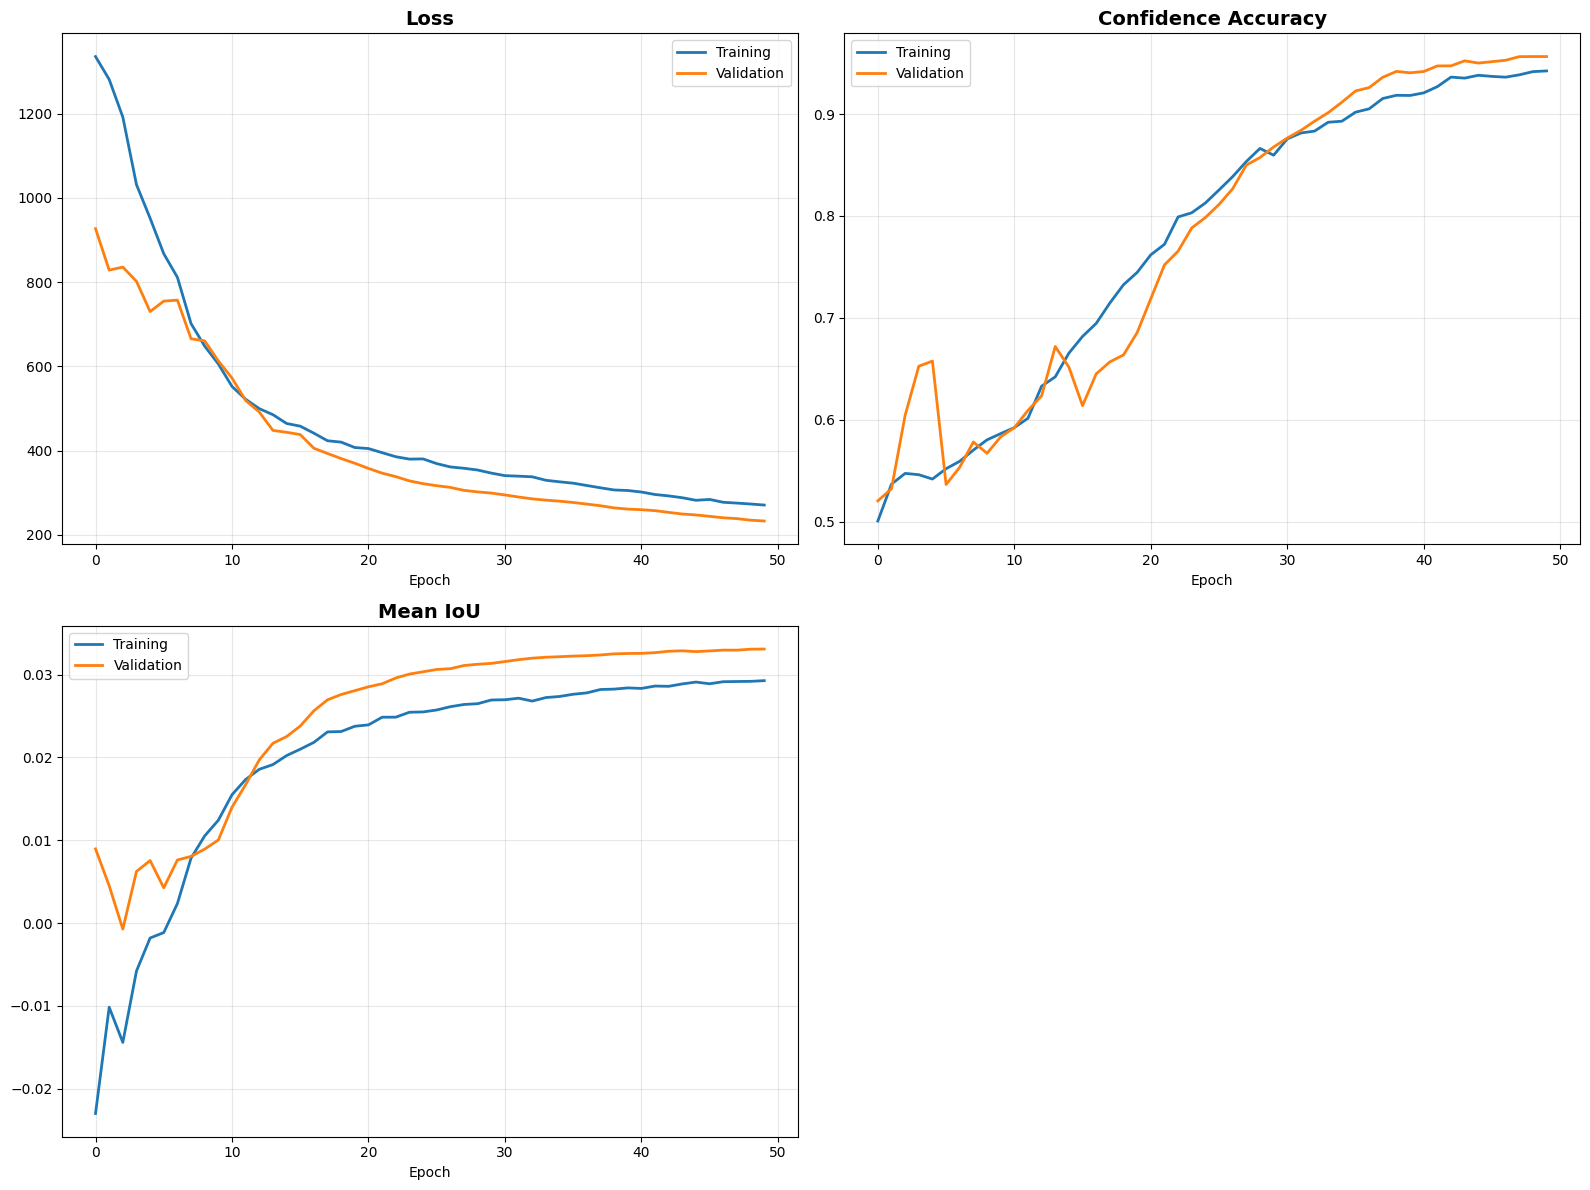


Final Metrics:
Training Loss: 270.5280
Validation Loss: 232.6316


In [23]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

axes[0, 0].plot(history.history['loss'], label='Training', linewidth=2)
axes[0, 0].plot(history.history['val_loss'], label='Validation', linewidth=2)
axes[0, 0].set_title('Loss', fontsize=14, weight='bold')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(history.history['confidence_accuracy'], label='Training', linewidth=2)
axes[0, 1].plot(history.history['val_confidence_accuracy'], label='Validation', linewidth=2)
axes[0, 1].set_title('Confidence Accuracy', fontsize=14, weight='bold')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].plot(history.history['mean_iou'], label='Training', linewidth=2)
axes[1, 0].plot(history.history['val_mean_iou'], label='Validation', linewidth=2)
axes[1, 0].set_title('Mean IoU', fontsize=14, weight='bold')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

print("\nFinal Metrics:")
print(f"Training Loss: {history.history['loss'][-1]:.4f}")
print(f"Validation Loss: {history.history['val_loss'][-1]:.4f}")

## 14. Inference & Prediction Functions

In [24]:
def decode_predictions(predictions, confidence_threshold=0.5):
    detections = []
    for row in range(GRID_SIZE):
        for col in range(GRID_SIZE):
            cell_pred = predictions[row, col]
            confidence = 1 / (1 + np.exp(-cell_pred[0]))

            if confidence < confidence_threshold:
                continue

            cx, cy, w, h = cell_pred[1:5]
            xmin = max(0, cx - w / 2)
            ymin = max(0, cy - h / 2)
            xmax = min(1, cx + w / 2)
            ymax = min(1, cy + h / 2)

            class_probs = np.exp(cell_pred[5:]) / np.sum(np.exp(cell_pred[5:]))
            class_id = np.argmax(class_probs)
            final_conf = confidence * class_probs[class_id]

            if final_conf >= confidence_threshold:
                detections.append([xmin, ymin, xmax, ymax, final_conf, class_id, INV_CLASS_MAP[class_id]])

    return detections

def calculate_iou(box1, box2):
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])
    intersection = max(0, x2 - x1) * max(0, y2 - y1)
    area1 = (box1[2] - box1[0]) * (box1[3] - box1[1])
    area2 = (box2[2] - box2[0]) * (box2[3] - box2[1])
    union = area1 + area2 - intersection
    return intersection / (union + 1e-6)

def non_max_suppression(detections, iou_threshold=0.5):
    if len(detections) == 0:
        return []
    detections = sorted(detections, key=lambda x: x[4], reverse=True)
    keep = []
    while len(detections) > 0:
        current = detections.pop(0)
        keep.append(current)
        detections = [det for det in detections if calculate_iou(current, det) < iou_threshold]
    return keep

def predict_and_visualize(model, image, ground_truth_boxes=None, confidence_threshold=0.5):
    img_batch = np.expand_dims(image, axis=0)
    predictions = model.predict(img_batch, verbose=0)[0]
    detections = decode_predictions(predictions, confidence_threshold)
    detections = non_max_suppression(detections, 0.5)

    fig, ax = plt.subplots(1, figsize=(12, 12))
    ax.imshow(image)
    img_h, img_w = image.shape[:2]

    if ground_truth_boxes:
        for box in ground_truth_boxes:
            xmin, ymin, xmax, ymax, label = box
            xmin, ymin, xmax, ymax = xmin * img_w, ymin * img_h, xmax * img_w, ymax * img_h
            rect = patches.Rectangle((xmin, ymin), xmax - xmin, ymax - ymin,
                                    linewidth=3, edgecolor='lime', facecolor='none', linestyle='--')
            ax.add_patch(rect)
            ax.text(xmin, ymin - 10, f"GT: {INV_CLASS_MAP[int(label)]}", color='white',
                   fontsize=11, weight='bold', bbox=dict(facecolor='lime', alpha=0.7, pad=2))

    for det in detections:
        xmin, ymin, xmax, ymax, conf, class_id, class_name = det
        xmin, ymin, xmax, ymax = xmin * img_w, ymin * img_h, xmax * img_w, ymax * img_h
        rect = patches.Rectangle((xmin, ymin), xmax - xmin, ymax - ymin,
                                linewidth=3, edgecolor='red', facecolor='none')
        ax.add_patch(rect)
        ax.text(xmin, ymax + 20, f"{class_name}: {conf:.2f}", color='white',
               fontsize=11, weight='bold', bbox=dict(facecolor='red', alpha=0.7, pad=2))

    ax.axis('off')
    ax.set_title('Detection Results', fontsize=14, weight='bold')
    plt.show()

    print(f"\nDetections: {len(detections)}")
    for i, det in enumerate(detections, 1):
        print(f"  {i}. {det[6]} (confidence: {det[4]:.3f})")

print("Inference functions defined!")

Inference functions defined!


## 15. Model Evaluation

In [25]:
print("Evaluating on Validation Set...")
val_results = model.evaluate(X_val, y_val, batch_size=BATCH_SIZE, verbose=1)
print(f"\nValidation Loss: {val_results[0]:.4f}")
print(f"Confidence Accuracy: {val_results[1]:.4f}")
print(f"Mean IoU: {val_results[2]:.4f}")

print("\nEvaluating on Test Set...")
test_results = model.evaluate(X_test, y_test, batch_size=BATCH_SIZE, verbose=1)
print(f"\nTest Loss: {test_results[0]:.4f}")
print(f"Confidence Accuracy: {test_results[1]:.4f}")
print(f"Mean IoU: {test_results[2]:.4f}")

Evaluating on Validation Set...
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - confidence_accuracy: 0.9569 - loss: 233.8994 - mean_iou: 0.0338

Validation Loss: 232.6316
Confidence Accuracy: 0.9564
Mean IoU: 0.0331

Evaluating on Test Set...
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - confidence_accuracy: 0.9614 - loss: 237.5043 - mean_iou: 0.0294

Test Loss: 223.0461
Confidence Accuracy: 0.9637
Mean IoU: 0.0281


## 16. Visual Results on Test Samples

Visualizing predictions on test samples...

Test Sample 1/5


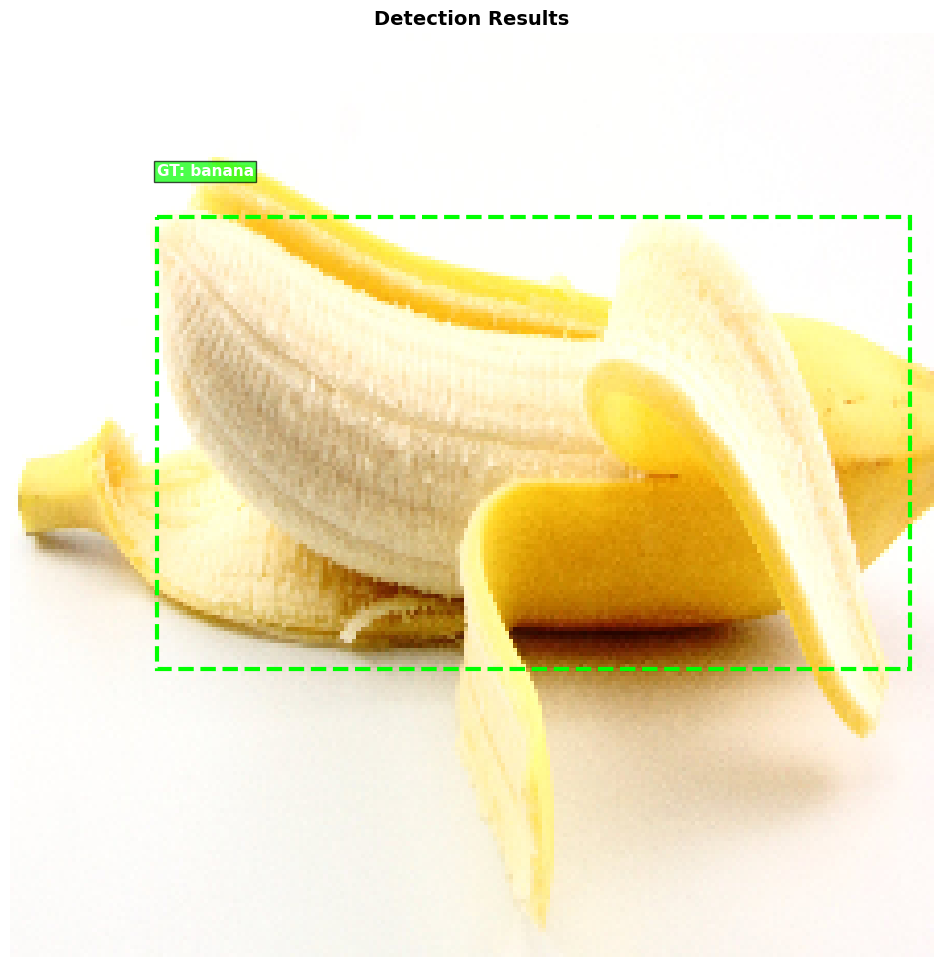


Detections: 0

Test Sample 2/5


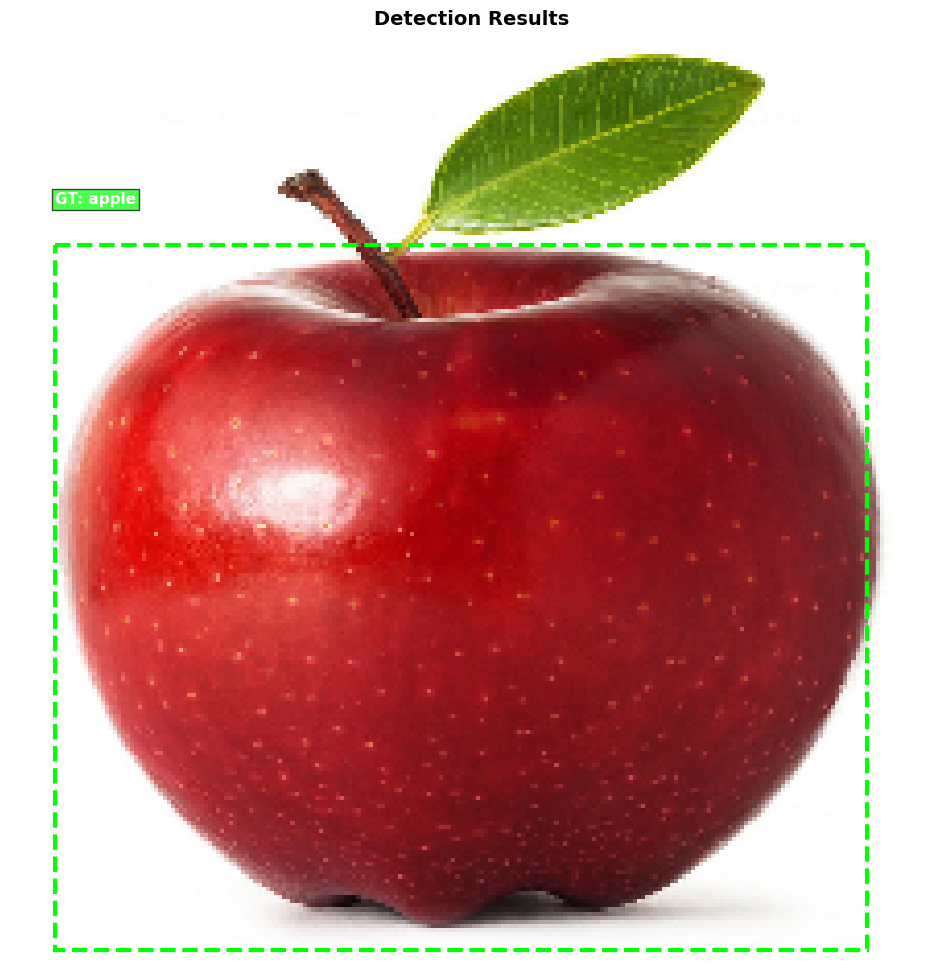


Detections: 0

Test Sample 3/5


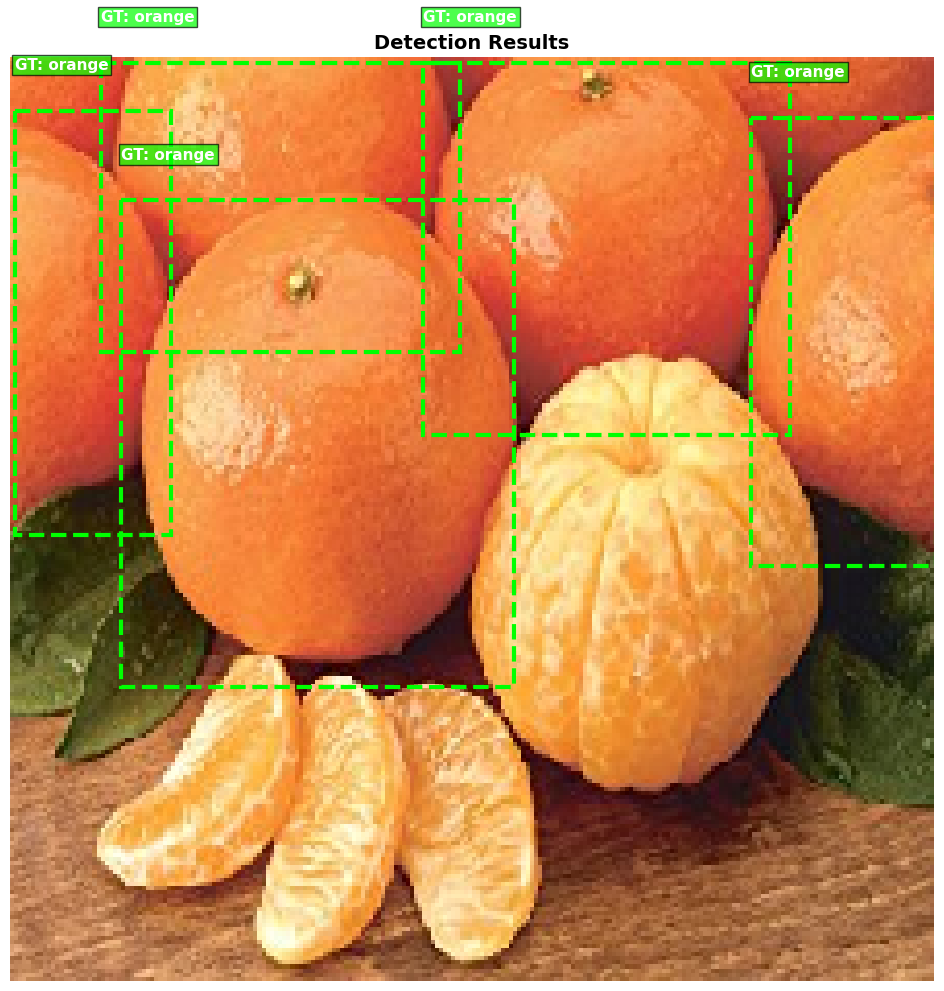


Detections: 0

Test Sample 4/5


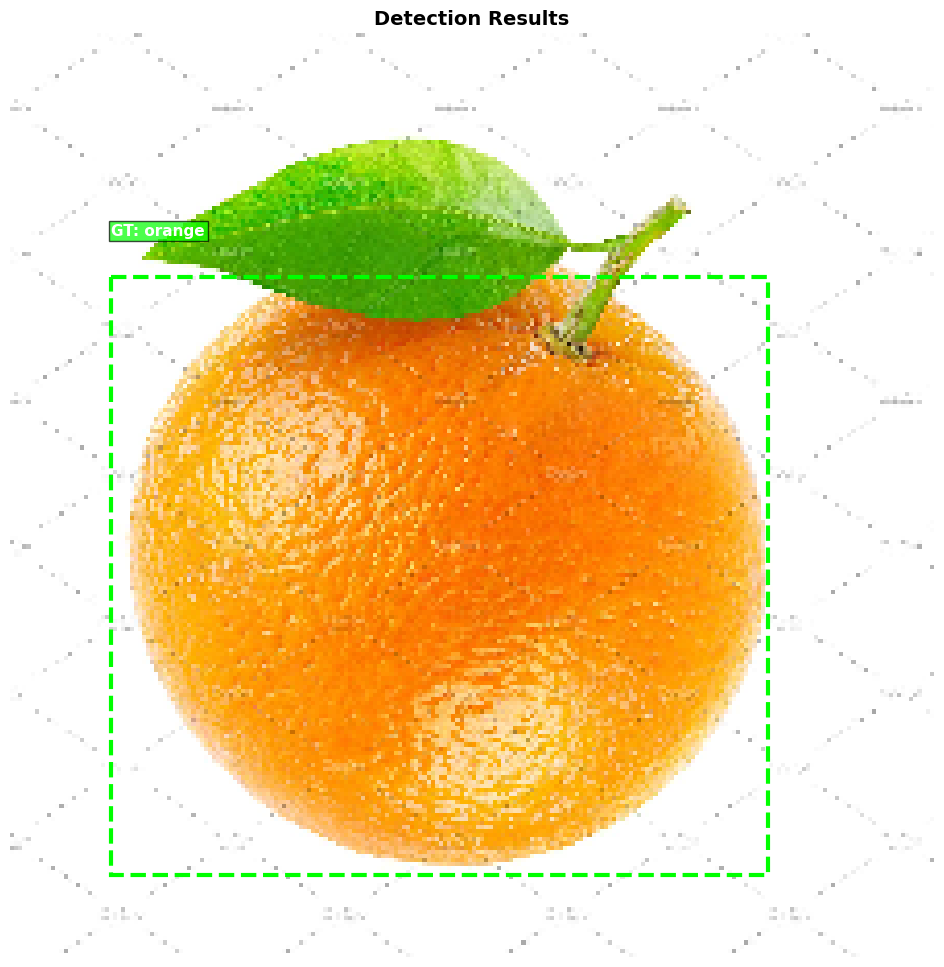


Detections: 0

Test Sample 5/5


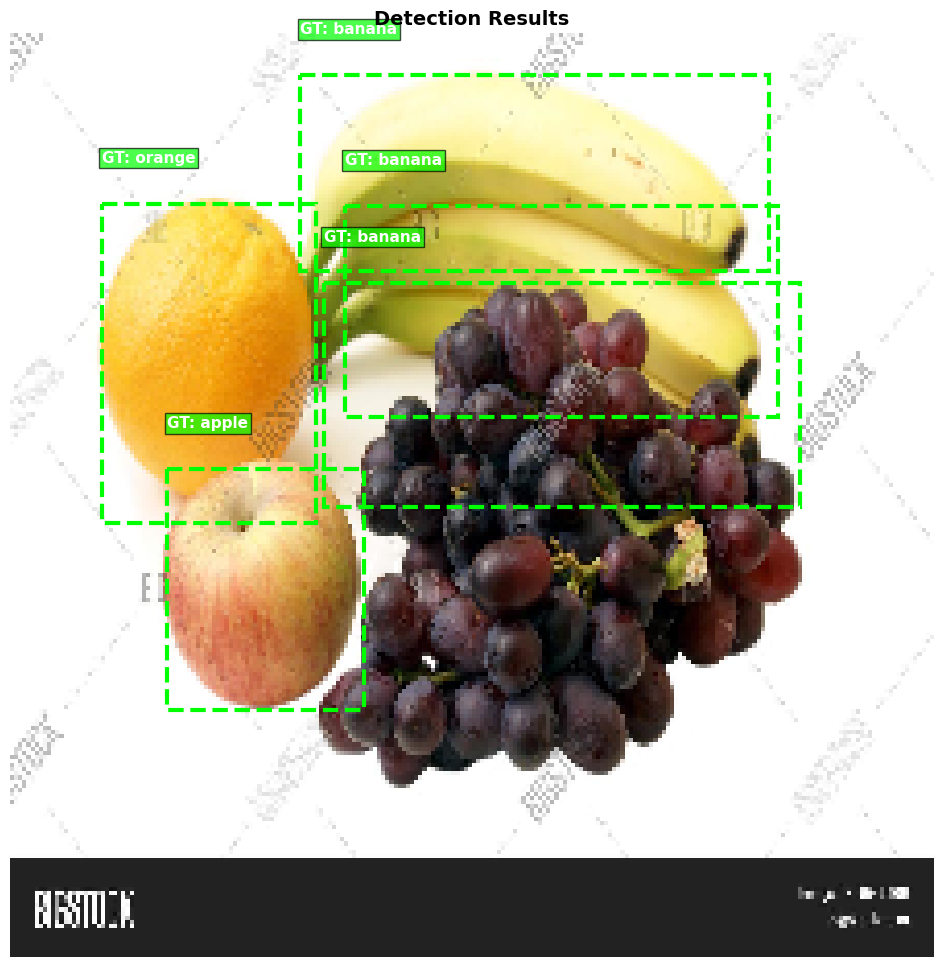


Detections: 0


In [26]:
print("Visualizing predictions on test samples...")
num_samples = 5
test_indices = random.sample(range(len(X_test)), min(num_samples, len(X_test)))

for i, idx in enumerate(test_indices, 1):
    print(f"\nTest Sample {i}/{num_samples}")
    predict_and_visualize(model, X_test[idx], test_annotations[idx], confidence_threshold=0.5)

## 17. Save Final Model

In [27]:
model_path = f"/content/{MODEL_TO_SAVE}"
model.save(model_path)

print(f"\n{'=' * 60}")
print(f"Model saved successfully!")
print(f"Location: {model_path}")
print(f"{'=' * 60}")

file_size = os.path.getsize(model_path) / (1024 * 1024)
print(f"\nModel file size: {file_size:.2f} MB")

print("\nTesting model loading...")
try:
    loaded_model = keras.models.load_model(
        model_path,
        custom_objects={
            'detection_loss': detection_loss,
            'confidence_accuracy': confidence_accuracy,
            'mean_iou': mean_iou
        }
    )
    print("✓ Model loaded successfully!")
    test_pred = loaded_model.predict(X_test[:1], verbose=0)
    print(f"✓ Inference test passed! Output shape: {test_pred.shape}")
except Exception as e:
    print(f"✗ Error: {e}")


Model saved successfully!
Location: /content/fruit_detector_v1.keras

Model file size: 58.02 MB

Testing model loading...
✓ Model loaded successfully!
✓ Inference test passed! Output shape: (1, 7, 7, 8)


## 18. Summary & Next Steps

### Model Summary

This notebook implemented an advanced Single Shot Detection (SSD) model for fruit detection using:

**Architecture:**
- Pre-trained MobileNetV2 backbone (Transfer Learning)
- Custom detection head with 7x7 grid
- Output: Confidence + Bounding Box + Class predictions

**Training Strategy:**
- Advanced loss functions (Focal Loss + Smooth L1)
- Data augmentation (flips, brightness, contrast)
- Early stopping and learning rate scheduling
- Model checkpointing

**Key Features:**
- Proper XML parsing with error handling
- Normalized bounding box coordinates
- Non-Maximum Suppression (NMS)
- Comprehensive evaluation metrics

### Next Steps

1. **Hyperparameter Tuning:** Experiment with different grid sizes, loss weights, and confidence thresholds
2. **Model Improvements:** Try other backbones (ResNet50, EfficientNet), implement anchor boxes
3. **Data Enhancements:** Collect more training data, add more augmentation techniques
4. **Deployment:** Convert to TensorFlow Lite for mobile, optimize for inference speed

### Usage Example

```python
# Load the saved model
model = keras.models.load_model(
    'fruit_detector_v1.keras',
    custom_objects={
        'detection_loss': detection_loss,
        'confidence_accuracy': confidence_accuracy,
        'mean_iou': mean_iou
    }
)

# Make predictions
image = load_and_preprocess_image('path/to/image.jpg')
predictions = model.predict(np.expand_dims(image, axis=0))
detections = decode_predictions(predictions[0])
```

---

**End of Notebook**